In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sse_core.compiler.builder import SSECompiler
from sse_core.compiler.parser import SSEParser
from sse_core.compiler.units import E_CHARGE
from sse_core.solvers.gillespie import GillespieSolver

In [2]:
# Thermal voltage
V_THERMAL = 26.0e-3

# Paper parameters for the p-bit
C_G = 50.0e-18
C_O = 1.0e-2 * C_G
SLOPE_FACTOR = 1.0

# MOSFET parameters: these only set the time scale
V_THRESHOLD = 4.0 * V_THERMAL
T0 = 1.0e-9

I0 = (
    E_CHARGE
    / T0
    * np.exp(
        V_THRESHOLD
        / (SLOPE_FACTOR * V_THERMAL)
    )
)

# First unbiased operating point from Fig. 14(b)
VDD_OVER_VT = 1.1

VDD = VDD_OVER_VT * V_THERMAL
VSS = -VDD

print(f"V_T       = {V_THERMAL * 1e3:.3f} mV")
print(f"C_g       = {C_G * 1e18:.3f} aF")
print(f"C_o       = {C_O * 1e18:.3f} aF")
print(f"Vdd / V_T = {VDD_OVER_VT:.3f}")
print(f"Vdd       = {VDD:.6f} V")
print(f"Vss       = {VSS:.6f} V")
print(f"I0        = {I0:.6e} A")
print(f"t0        = {T0:.3e} s")

V_T       = 26.000 mV
C_g       = 50.000 aF
C_o       = 0.500 aF
Vdd / V_T = 1.100
Vdd       = 0.028600 V
Vss       = -0.028600 V
I0        = 8.747588e-09 A
t0        = 1.000e-09 s


In [3]:
from textwrap import dedent


def build_unbiased_pbit_yaml(
    *,
    t_finish,
    seed,
):
    """
    Two cross-coupled CMOS inverters forming the unbiased p-bit core.

    Inverter 1:
        output = v1
        input  = v2

    Inverter 2:
        output = v2
        input  = v1
    """

    return dedent(
        f"""
        schema_version: "1.0.0"

        simulation:
          solver: "gillespie"
          t_finish: {t_finish:.17e}
          v_th: {V_THERMAL:.17e}
          seed: {seed}

        nodes:
          free:
            - name: "v1"
              initial_charge: 0

            - name: "v2"
              initial_charge: 0

          regulated:
            - name: "vdd"
              type: "constant"
              value: {VDD:.17e}

            - name: "vss"
              type: "constant"
              value: {VSS:.17e}

        components:
          # Output capacitances of inverter 1
          - type: "capacitor"
            name: "Co_1_dd"
            terminals: ["v1", "vdd"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Co_1_ss"
            terminals: ["v1", "vss"]
            specs:
              capacitance: {C_O:.17e}

          # Output capacitances of inverter 2
          - type: "capacitor"
            name: "Co_2_dd"
            terminals: ["v2", "vdd"]
            specs:
              capacitance: {C_O:.17e}

          - type: "capacitor"
            name: "Co_2_ss"
            terminals: ["v2", "vss"]
            specs:
              capacitance: {C_O:.17e}

          # Gate capacitances of inverter 1.
          # Its input is the opposite output, v2.
          - type: "capacitor"
            name: "Cg_1_dd"
            terminals: ["v2", "vdd"]
            specs:
              capacitance: {C_G:.17e}

          - type: "capacitor"
            name: "Cg_1_ss"
            terminals: ["v2", "vss"]
            specs:
              capacitance: {C_G:.17e}

          # Gate capacitances of inverter 2.
          # Its input is the opposite output, v1.
          - type: "capacitor"
            name: "Cg_2_dd"
            terminals: ["v1", "vdd"]
            specs:
              capacitance: {C_G:.17e}

          - type: "capacitor"
            name: "Cg_2_ss"
            terminals: ["v1", "vss"]
            specs:
              capacitance: {C_G:.17e}

          # Inverter 1: v2 -> v1
          - type: "n_channel_mosfet"
            name: "NMOS_1"
            terminals:
              drain: "v1"
              gate: "v2"
              source: "vss"
              bulk: "vss"
            specs:
              I0: {I0:.17e}
              VT: {V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "p_channel_mosfet"
            name: "PMOS_1"
            terminals:
              drain: "v1"
              gate: "v2"
              source: "vdd"
              bulk: "vdd"
            specs:
              I0: {I0:.17e}
              VT: {-V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          # Inverter 2: v1 -> v2
          - type: "n_channel_mosfet"
            name: "NMOS_2"
            terminals:
              drain: "v2"
              gate: "v1"
              source: "vss"
              bulk: "vss"
            specs:
              I0: {I0:.17e}
              VT: {V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}

          - type: "p_channel_mosfet"
            name: "PMOS_2"
            terminals:
              drain: "v2"
              gate: "v1"
              source: "vdd"
              bulk: "vdd"
            specs:
              I0: {I0:.17e}
              VT: {-V_THRESHOLD:.17e}
              n: {SLOPE_FACTOR:.17e}
        """
    )

In [4]:
PBIT_T_FINISH = 3.0e4 * T0
PBIT_SEED = 2201

pbit_yaml = build_unbiased_pbit_yaml(
    t_finish=PBIT_T_FINISH,
    seed=PBIT_SEED,
)

pbit_netlist = SSEParser.parse_string(
    pbit_yaml
)

pbit_assembly = SSECompiler.compile_string(
    pbit_yaml
)

# Each free node is both:
#   - one inverter output: 2 Co
#   - the other inverter input: 2 Cg
#
# Therefore its total capacitance is 2(Co + Cg).
expected_node_capacitance = 2.0 * (
    C_O + C_G
)

expected_C = (
    expected_node_capacitance
    * np.eye(2)
)

actual_C = np.linalg.inv(
    pbit_assembly.C_inv
)

np.testing.assert_allclose(
    actual_C,
    expected_C,
    rtol=1.0e-12,
    atol=1.0e-30,
)

print("Free nodes:      ", pbit_assembly.free_names)
print("Regulated nodes: ", pbit_assembly.regulated_names)
print()
print("Compiled free capacitance matrix:")
print(actual_C / 1.0e-18)
print("units: aF")

Free nodes:       ['v1', 'v2']
Regulated nodes:  ['vdd', 'vss']

Compiled free capacitance matrix:
[[101.   0.]
 [  0. 101.]]
units: aF


In [5]:
PILOT_DURATION = 3.0e3 * T0
PILOT_MAX_EVENTS = 250_000
PILOT_SEED = 2201

pilot_yaml = build_unbiased_pbit_yaml(
    t_finish=PILOT_DURATION,
    seed=PILOT_SEED,
)

pilot_netlist = SSEParser.parse_string(
    pilot_yaml
)

pilot_assembly = SSECompiler.compile_string(
    pilot_yaml
)

pilot_solver = GillespieSolver(
    pilot_netlist,
    pilot_assembly,
)

regulated_values = {
    node.name: node.value
    for node in pilot_netlist.nodes.regulated
}

pilot_vr = np.asarray(
    [
        regulated_values[name]
        for name in pilot_assembly.regulated_names
    ],
    dtype=np.float64,
)

# Start near one deterministic memory state:
#
#     v1 ≈ +Vdd
#     v2 ≈ -Vdd
#
# Native charge has inverted polarity:
#
#     Q_physical = -qe * q_native.
node_capacitance = 2.0 * (
    C_G + C_O
)

well_charge_count = int(
    np.rint(
        node_capacitance
        * VDD
        / E_CHARGE
    )
)

pilot_q_initial = np.array(
    [
        -well_charge_count,
        +well_charge_count,
    ],
    dtype=np.int64,
)

print("Free-node order:", pilot_assembly.free_names)
print("Initial native charge:", pilot_q_initial)
print("Approximate well charge:", well_charge_count)

Free-node order: ['v1', 'v2']
Initial native charge: [-18  18]
Approximate well charge: 18


In [6]:
pilot_history = pilot_solver.simulate(
    q_init=pilot_q_initial,
    vr=pilot_vr,
    max_steps=PILOT_MAX_EVENTS,
)

number_of_events = len(
    pilot_history["events"]["time"]
)

v1 = pilot_history["potentials"]["v1"]
v2 = pilot_history["potentials"]["v2"]

print(
    f"Completed:          {pilot_history['completed']}"
)
print(
    f"Termination:        {pilot_history['termination_reason']}"
)
print(
    f"Executed events:    {number_of_events:,}"
)
print(
    f"Duration / t0:      "
    f"{pilot_history['time'][-1] / T0:,.1f}"
)
print(
    f"v1 range / Vdd:     "
    f"[{v1.min() / VDD:.3f}, {v1.max() / VDD:.3f}]"
)
print(
    f"v2 range / Vdd:     "
    f"[{v2.min() / VDD:.3f}, {v2.max() / VDD:.3f}]"
)

assert pilot_history["completed"]

Completed:          True
Termination:        t_finish
Executed events:    94,919
Duration / t0:      3,000.0
v1 range / Vdd:     [-1.775, 1.830]
v2 range / Vdd:     [-1.775, 1.775]


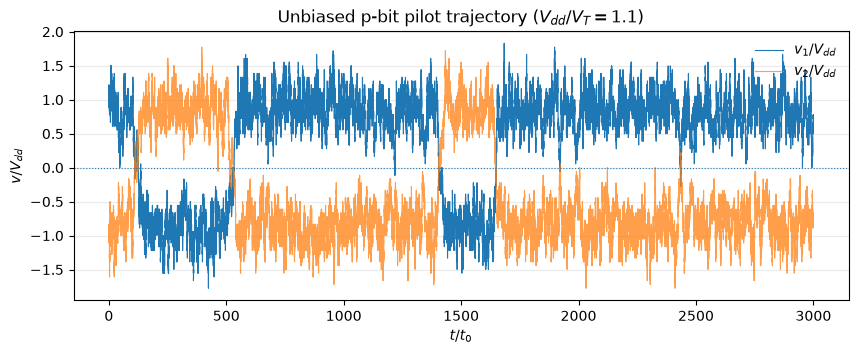

In [7]:
pilot_time_over_t0 = (
    pilot_history["time"] / T0
)

pilot_v1_over_vdd = (
    pilot_history["potentials"]["v1"] / VDD
)

pilot_v2_over_vdd = (
    pilot_history["potentials"]["v2"] / VDD
)

fig, axis = plt.subplots(
    figsize=(10.0, 3.5),
)

axis.step(
    pilot_time_over_t0,
    pilot_v1_over_vdd,
    where="post",
    linewidth=0.8,
    label=r"$v_1/V_{dd}$",
)

axis.step(
    pilot_time_over_t0,
    pilot_v2_over_vdd,
    where="post",
    linewidth=0.8,
    alpha=0.75,
    label=r"$v_2/V_{dd}$",
)

axis.axhline(
    0.0,
    linewidth=0.8,
    linestyle=":",
)

axis.set_xlabel(r"$t/t_0$")
axis.set_ylabel(r"$v/V_{dd}$")

axis.set_title(
    rf"Unbiased p-bit pilot trajectory "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$)"
)

axis.legend(
    frameon=False,
    loc="upper right",
)

axis.grid(
    axis="y",
    alpha=0.25,
)

plt.show()

In [8]:
# Residence-time-weighted sign correlation.
#
# State i occupies [time[i], time[i + 1]).
residence_time = np.diff(
    pilot_history["time"]
)

v1_interval = pilot_v1_over_vdd[:-1]
v2_interval = pilot_v2_over_vdd[:-1]

weighted_sign_product = np.sum(
    residence_time
    * np.sign(v1_interval)
    * np.sign(v2_interval)
) / np.sum(residence_time)

positive_v1_fraction = np.sum(
    residence_time[
        v1_interval > 0.0
    ]
) / np.sum(residence_time)

print(
    f"Weighted sign correlation: "
    f"{weighted_sign_product:.4f}"
)

print(
    f"Residence fraction v1 > 0: "
    f"{positive_v1_fraction:.4f}"
)

Weighted sign correlation: -0.9830
Residence fraction v1 > 0: 0.7795


In [9]:
FULL_DURATION = 3.0e4 * T0
FULL_MAX_EVENTS = 2_000_000
FULL_SEED = 2202

full_yaml = build_unbiased_pbit_yaml(
    t_finish=FULL_DURATION,
    seed=FULL_SEED,
)

full_netlist = SSEParser.parse_string(full_yaml)
full_assembly = SSECompiler.compile_string(full_yaml)

full_solver = GillespieSolver(
    full_netlist,
    full_assembly,
)

regulated_values = {
    node.name: node.value
    for node in full_netlist.nodes.regulated
}

full_vr = np.asarray(
    [
        regulated_values[name]
        for name in full_assembly.regulated_names
    ],
    dtype=np.float64,
)

full_history = full_solver.simulate(
    q_init=pilot_q_initial,
    vr=full_vr,
    max_steps=FULL_MAX_EVENTS,
)

print(
    f"Events:       "
    f"{len(full_history['events']['time']):,}"
)
print(
    f"Duration/t0:  "
    f"{full_history['time'][-1] / T0:,.1f}"
)
print(
    f"Completed:    "
    f"{full_history['completed']}"
)

Events:       951,398
Duration/t0:  30,000.0
Completed:    True


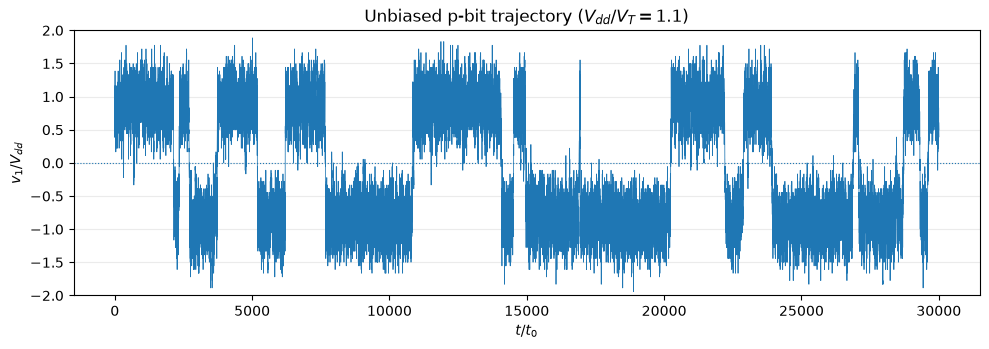

In [10]:
full_time_over_t0 = (
    full_history["time"] / T0
)

full_v1_over_vdd = (
    full_history["potentials"]["v1"] / VDD
)

# Reduce rendering cost only. The underlying simulation data remains
# unchanged and will be used in full for the histogram.
MAX_DISPLAY_POINTS = 250_000

display_stride = max(
    1,
    len(full_time_over_t0) // MAX_DISPLAY_POINTS,
)

display_indices = np.arange(
    0,
    len(full_time_over_t0),
    display_stride,
)

# Always retain the final point.
if display_indices[-1] != len(full_time_over_t0) - 1:
    display_indices = np.append(
        display_indices,
        len(full_time_over_t0) - 1,
    )

fig, axis = plt.subplots(
    figsize=(10.0, 3.6),
)

axis.plot(
    full_time_over_t0[display_indices],
    full_v1_over_vdd[display_indices],
    linewidth=0.55,
    rasterized=True,
)

axis.axhline(
    0.0,
    linestyle=":",
    linewidth=0.8,
)

axis.set_xlabel(r"$t/t_0$")
axis.set_ylabel(r"$v_1/V_{dd}$")

axis.set_title(
    rf"Unbiased p-bit trajectory "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$)"
)

axis.set_ylim(-2.0, 2.0)
axis.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

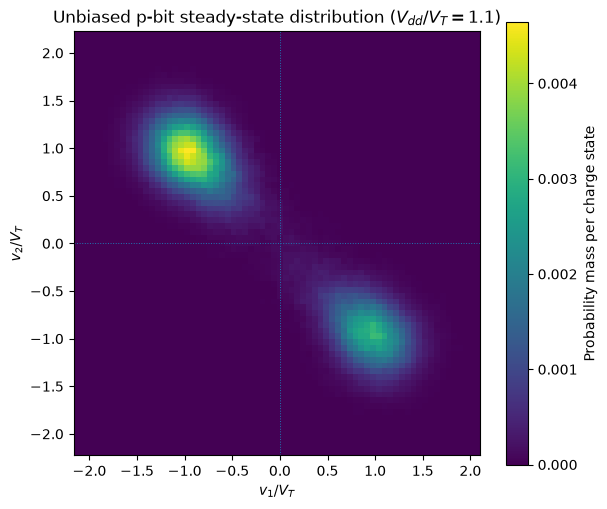

In [12]:
BURN_FRACTION = 0.10

time = np.asarray(
    full_history["time"],
    dtype=np.float64,
)

residence_time = np.diff(time)

burn_time = (
    time[0]
    + BURN_FRACTION
    * (time[-1] - time[0])
)

residence_time = np.maximum(
    0.0,
    time[1:]
    - np.maximum(time[:-1], burn_time),
)

index_v1 = full_assembly.free_names.index("v1")
index_v2 = full_assembly.free_names.index("v2")

q1 = full_history["charge"][:-1, index_v1]
q2 = full_history["charge"][:-1, index_v2]

keep = residence_time > 0.0

q1 = q1[keep]
q2 = q2[keep]
residence_time = residence_time[keep]

q1_levels = np.arange(
    q1.min(),
    q1.max() + 1,
    dtype=np.int64,
)

q2_levels = np.arange(
    q2.min(),
    q2.max() + 1,
    dtype=np.int64,
)

probability = np.zeros(
    (len(q2_levels), len(q1_levels)),
    dtype=np.float64,
)

np.add.at(
    probability,
    (
        q2 - q2_levels[0],
        q1 - q1_levels[0],
    ),
    residence_time,
)

probability /= probability.sum()

# The compiled free capacitance matrix is diagonal for this circuit.
np.testing.assert_allclose(
    full_assembly.C_inv[
        [index_v1, index_v2],
        [index_v2, index_v1],
    ],
    0.0,
    atol=1.0e-12,
)

voltage_offset = (
    -full_assembly.C_inv
    @ full_assembly.Cx
    @ full_vr
)

v1_centers = (
    voltage_offset[index_v1]
    - E_CHARGE
    * full_assembly.C_inv[index_v1, index_v1]
    * q1_levels
) / V_THERMAL

v2_centers = (
    voltage_offset[index_v2]
    - E_CHARGE
    * full_assembly.C_inv[index_v2, index_v2]
    * q2_levels
) / V_THERMAL


def centers_to_edges(centers):
    centers = np.asarray(centers)

    midpoints = 0.5 * (
        centers[:-1] + centers[1:]
    )

    return np.concatenate(
        [
            [
                centers[0]
                - 0.5 * (centers[1] - centers[0])
            ],
            midpoints,
            [
                centers[-1]
                + 0.5 * (centers[-1] - centers[-2])
            ],
        ]
    )


# Native electron count increases in the opposite direction to voltage.
# Reverse both axes so the plotted coordinates increase normally.
v1_centers = v1_centers[::-1]
v2_centers = v2_centers[::-1]
probability = probability[::-1, ::-1]

v1_edges = centers_to_edges(v1_centers)
v2_edges = centers_to_edges(v2_centers)

fig, axis = plt.subplots(
    figsize=(6.2, 5.3),
)

mesh = axis.pcolormesh(
    v1_edges,
    v2_edges,
    probability,
    shading="flat",
)

axis.axhline(
    0.0,
    linestyle=":",
    linewidth=0.7,
)

axis.axvline(
    0.0,
    linestyle=":",
    linewidth=0.7,
)

axis.set_xlabel(r"$v_1/V_T$")
axis.set_ylabel(r"$v_2/V_T$")

axis.set_title(
    rf"Unbiased p-bit steady-state distribution "
    rf"($V_{{dd}}/V_T={VDD_OVER_VT}$)"
)

axis.set_aspect("equal")

colorbar = fig.colorbar(
    mesh,
    ax=axis,
)

colorbar.set_label(
    "Probability mass per charge state"
)

plt.tight_layout()
plt.show()